In [1]:
import torch
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = "cpu"

# Modèle pré-entraîné — version légère
processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r18vd")
model     = RTDetrV2ForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r18vd")
model.eval()

print("✅ RT-DETR chargé")

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ RT-DETR chargé


In [2]:
def run_rtdetr(image_path, threshold=0.5):
    image  = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-processing
    results = processor.post_process_object_detection(
        outputs,
        target_sizes=torch.tensor([image.size[::-1]]),
        threshold=threshold
    )[0]
    
    boxes  = results["boxes"]
    scores = results["scores"]
    labels = results["labels"]
    
    print(f"✅ {len(boxes)} objets détectés")
    for box, score, label in zip(boxes, scores, labels):
        print(f"  [{score:.2f}] {model.config.id2label[label.item()]} | bbox: {box.tolist()}")
    
    return image, boxes, scores, labels

In [3]:
def visualize_rtdetr(image_path, threshold=0.5):
    image, boxes, scores, labels = run_rtdetr(image_path, threshold)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Original
    axes[0].imshow(image)
    axes[0].set_title("Image originale", fontsize=13)
    axes[0].axis("off")
    
    # Annoté
    axes[1].imshow(image)
    axes[1].set_title(f"RT-DETR — {len(boxes)} détections", fontsize=13)
    axes[1].axis("off")
    
    colors = plt.cm.tab20.colors
    
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.tolist()
        label_name      = model.config.id2label[label.item()]
        color           = colors[label.item() % len(colors)]
        
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.15
        )
        axes[1].add_patch(rect)
        rect2 = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        axes[1].add_patch(rect2)
        axes[1].text(
            x1, y1 - 4,
            f"{label_name} {score:.2f}",
            color="white", fontsize=8, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor="none")
        )
    
    plt.tight_layout()
    plt.savefig("resultat_rtdetr.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    return boxes, scores, labels


✅ 3 objets détectés
  [0.63] tvmonitor | bbox: [2.4207990169525146, 1.6195639371871948, 1388.9951171875, 873.2113037109375]
  [0.52] laptop | bbox: [2.4207990169525146, 1.6195639371871948, 1388.9951171875, 873.2113037109375]
  [0.51] cell phone | bbox: [2.4207990169525146, 1.6195639371871948, 1388.9951171875, 873.2113037109375]


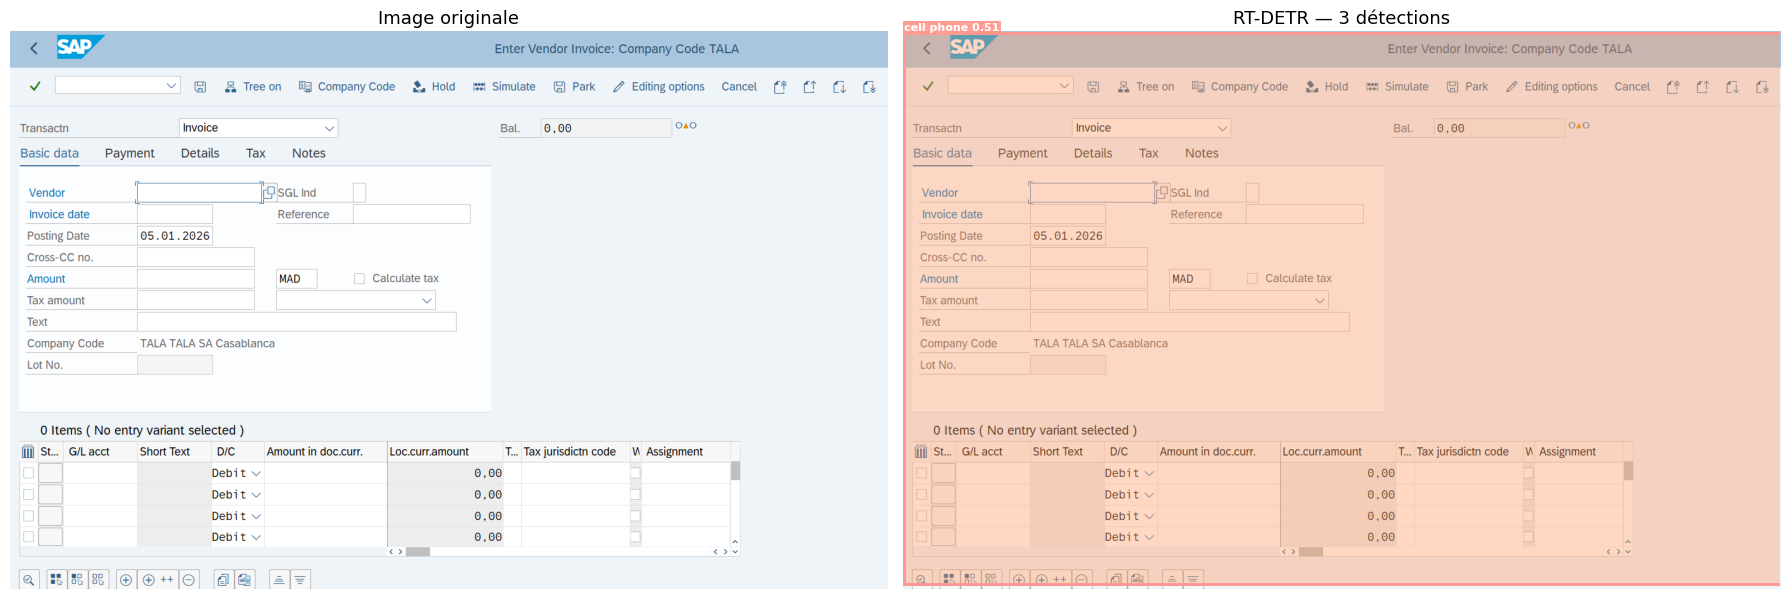

In [4]:
# Lancer
boxes, scores, labels = visualize_rtdetr("img_1767525774023-copy.png", threshold=0.5)